In [1]:
# Build on the MLP from scratchpad_mlp2 to arrive at an architecture similar to Google DeepMind's WaveNet Convolutional Neural Network

# so the motivation to not simply scale the MLP but rather implement the Wavenet CNN is:
# in the MLP, even with scaling, we are squashing all the data into a single vector (embedding) right at the beginning. There is no way around this

# We implemented the FlattenConsecutive Layer modeled off the WaveNet architecture
# We did not implement the forward pass of the WaveNet architecture, the "Gated Linear Layer" (GLU)
# So this is not a CNN, its just moving in that direction


import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

In [2]:
# Notice how PyTorch's matrix multiply works in higher dimensions:
print((torch.randn(4, 80) @ torch.randn(80, 200)).shape)
print((torch.randn(4, 2, 5, 80) @ torch.randn(80, 200)).shape)

# consider 8 characters of context:
# 1 2 3 4 5 6 7 8
# we dont want to flatten out this entire context into a single vector and multiply it by a weight matrix
# Instead:
# (1 2) (3 4) (5 6) (7 8)
# Each pair will be flattened and multiplied by a weight matrix
# Each pair is processed in parallel

torch.Size([4, 200])
torch.Size([4, 2, 5, 200])


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [4]:
random.seed(42)
random.shuffle(words)

In [5]:
# build the dataset

block_size = 8 # context length

def build_dataset(words):
    X, Y = [], []
    for w in words[:10000]:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [6]:
for x,y in zip(Xtr[:10], Ytr[:10]):
    print(''.join(itos[i.item()] for i in x), '---->', itos[y.item()])

........ ----> y
.......y ----> u
......yu ----> h
.....yuh ----> e
....yuhe ----> n
...yuhen ----> g
..yuheng ----> .
........ ----> d
.......d ----> i
......di ----> o


In [7]:
# Layer Module Definition (PyTorch API)

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # kaiming init
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (learnable via backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (not learnable, but part of the state)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        # calculate forward pass
        if self.training:
            # With FlattenConsecutive Layer, we have to specify the dimension to average over for running mean and var
            # We get an extra "Batch Dimension" (?)
            # notes about this at ~40 min in lecture
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            self.mean = x.mean(dim, keepdim=True)
            self.var = x.var(dim, keepdim=True)
        else:
            self.mean = self.running_mean
            self.var = self.running_var
        xhat = (x - self.mean) / torch.sqrt(self.var + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update running stats
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * self.var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []


class Embedding:
    
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
        
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive: 
    
    def __init__(self, n):
        self.n = n # n is the number of consecutive tokens to flatten together
    
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
    
class Sequential:
    
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [8]:
torch.manual_seed(42)

In [9]:
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),])

# parameters init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # make last layer less confident # ? 
    
parameters = model.parameters()
for p in parameters:
    p.requires_grad = True

In [10]:
# Stochastic Gradient Descent
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update gradients
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} --- loss: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000 --- loss: 3.2991
  10000/ 200000 --- loss: 2.4494
  20000/ 200000 --- loss: 2.4350
  30000/ 200000 --- loss: 1.8365
  40000/ 200000 --- loss: 1.7948
  50000/ 200000 --- loss: 2.1193
  60000/ 200000 --- loss: 1.7537
  70000/ 200000 --- loss: 1.8437
  80000/ 200000 --- loss: 1.9553
  90000/ 200000 --- loss: 1.6176
 100000/ 200000 --- loss: 1.7575
 110000/ 200000 --- loss: 1.1342
 120000/ 200000 --- loss: 1.4846
 130000/ 200000 --- loss: 1.2197
 140000/ 200000 --- loss: 1.6362
 150000/ 200000 --- loss: 1.2924
 160000/ 200000 --- loss: 1.2923
 170000/ 200000 --- loss: 1.5971
 180000/ 200000 --- loss: 1.8948
 190000/ 200000 --- loss: 1.3934


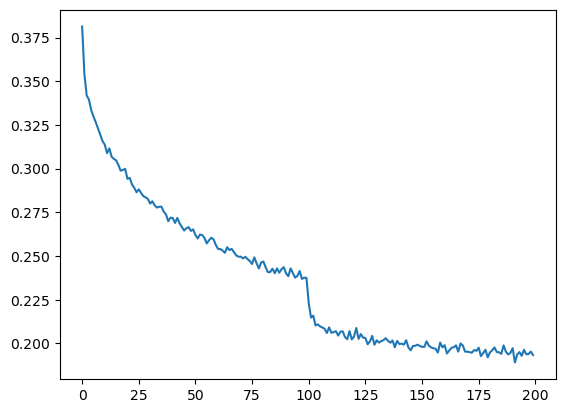

In [11]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [12]:
# put layers into eval mode
for layer in model.layers:
    layer.training = False

In [13]:
# evaluate the loss on dev set
@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 
            'dev': (Xdev, Ydev), 
            'test': (Xte, Yte),
            }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('dev')

train loss: 1.5109
dev loss: 2.2752


In [28]:
# sample from the model

for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
        # forward pass
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(ix)
    print(''.join(itos[i] for i in out))

jarey
asson
evaline
gincie
elmina
randi
chiabez
areahra
saul
jame
amelius
dars
omar
khaya
ren
chiana
nslie
iyana
otonet
linstre


In [15]:
# Notes about Convolutional Neural Networks (CNNs):
# The use of convolution is purely for efficiency, and doesnt actually change what the model is doing

In [16]:
# consider the examples:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
    print(''.join(itos[ix.item()] for ix in x), '---->', itos[y.item()])

........ ----> d
.......d ----> i
......di ----> o
.....dio ----> n
....dion ----> d
...diond ----> r
..diondr ----> e
.diondre ----> .


In [17]:
# forward pass for a single example:
logits = model(Xtr[[7]])
logits.shape

torch.Size([1, 27])

In [18]:
# forward all examples:
logits = torch.zeros(8,27)
for i in range(8):
    logits[i] = model(Xtr[[7+i]])
logits.shape

torch.Size([8, 27])

In [19]:
# When you convolve two distributions, think of one of the distributions as a kernel of filter that you are evaluation every point of the other distrinution against
# convolution is an integral (or sum), so its like a for-loop over space (or whatever the sample space of the distribution is)
# So here, the kernel is the linear layer (weight matrix), and the distribution that we are the input data against this kernel
# Thus in summary, convolution allows us to efficiently forward the linear layer over the input sequence